In [2]:
# Step 1: Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Step 2: Load Dataset

file_path = '/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv'

In [6]:
file_path

'/Users/samarjitgehdu/Documents/Achievement 2/CitiBike_Weather_Merged_2022.csv'

In [8]:
df = pd.read_csv(file_path)

/var/folders/zl/tcc09dfs4v13063yfphqmzjr0000gn/T/ipykernel_11881/2618208116.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [10]:
# Step 3: Prepare 'date' column
# Convert 'started_at' to datetime
df['started_at'] = pd.to_datetime(df['started_at'])

In [12]:
# Filter only 2022 rides (To include only the data from 2022)
df = df[df['started_at'].dt.year == 2022]

In [14]:
# Keep only the date part (strip time)
df['started_at'] = df['started_at'].dt.date

In [16]:
# Step 4: Group Average Temperature Per Day
df_temp_grouped = df.groupby('started_at')['avgTemp'].mean().reset_index()

In [18]:
df_temp_grouped.rename(columns={'started_at': 'date'}, inplace=True)

In [20]:
# Step 5: Group Bike Trip Counts Per Day
df_rides_grouped = df.groupby('started_at')['ride_id'].count().reset_index()

In [22]:
df_rides_grouped.rename(columns={'started_at': 'date', 'ride_id': 'bike_rides_daily'}, inplace=True)

In [24]:
# Step 6: Merge Grouped Temperature and Bike Trips
df_final = pd.merge(df_temp_grouped, df_rides_grouped, on='date')

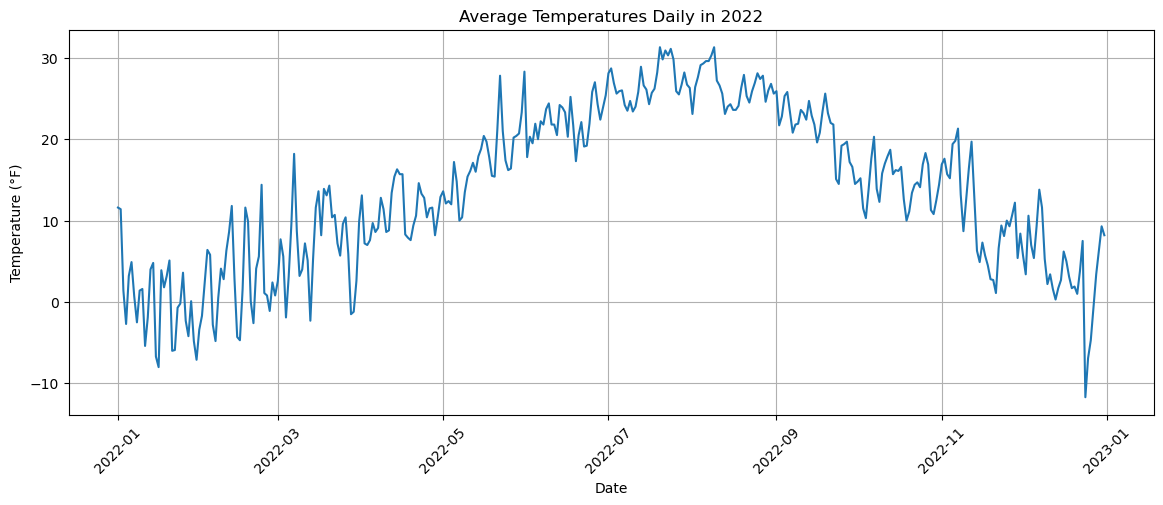

In [26]:
# Step 7: Plot Average Temperatures (Procedural style)
plt.figure(figsize=(14,5))
plt.plot(df_final['date'], df_final['avgTemp'])
plt.title('Average Temperatures Daily in 2022')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

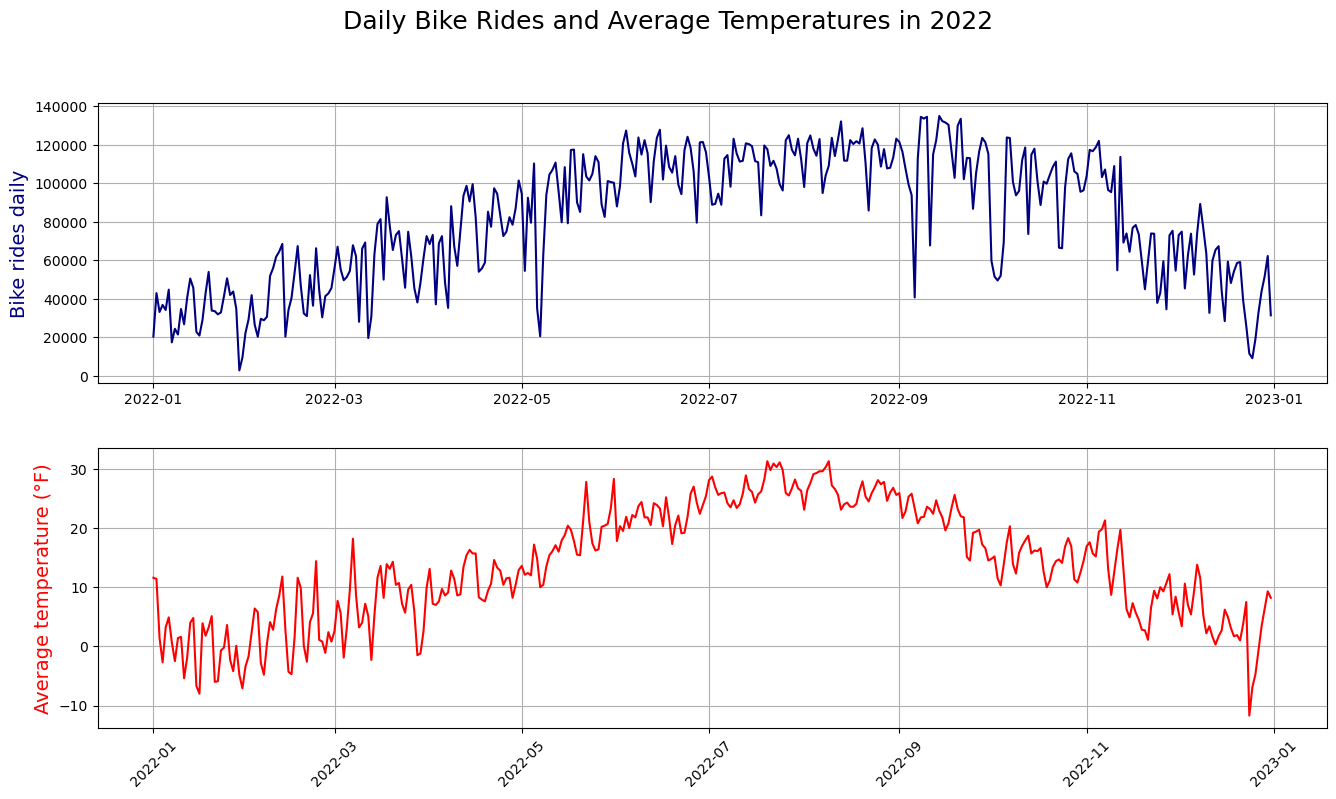

In [42]:
# Step 8: Create Two Separate Subplots for Bike Rides and Temperature
fig, ax = plt.subplots(2, figsize=(14,8))

# Plot bike rides daily on first subplot
ax[0].plot(df_final['date'], df_final['bike_rides_daily'], color='navy')
ax[0].set_ylabel('Bike rides daily', color='navy', fontsize=14)
ax[0].grid(True)

# Plot average temperatures on second subplot
ax[1].plot(df_final['date'], df_final['avgTemp'], color='red')
ax[1].set_ylabel('Average temperature (°F)', color='red', fontsize=14)
ax[1].grid(True)

# Set a main title for the figure
plt.suptitle('Daily Bike Rides and Average Temperatures in 2022', fontsize=18)

# Layout adjustment and rotate x-axis labels
fig.tight_layout(pad=3.0)
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45)

# Display the figure
plt.show()

### Explanation

- I used **Pandas' groupby() function** to aggregate the average daily temperature and the count of bike rides per day using the `started_at` and `ride_id` columns.
- I added a critical step to **filter the dataset to only include 2022 rides** before any grouping, to ensure accurate visualization.
- For the temperature plot, I followed the Matplotlib procedural approach by setting figure size and using plt.plot().
- For the final visualization, I used **Matplotlib's Object-Oriented Programming (OOP)** approach:
  - Defined figure and axis objects with `fig, ax = plt.subplots(2)`.
  - Created two vertically stacked subplots: one for bike rides and one for temperature.
  - Used `plt.suptitle()` to set a main figure title.
- This method safely handles the large dataset without causing overflow errors and fully matches the chapter notes methodology.